# INTRODUCCION

El presente análisis fue desarrollado para el departamento de analítica de Showz, empresa de venta de entradas para eventos. A partir de registros de visitas, órdenes y gastos de marketing del período junio 2017 - mayo 2018, se busca responder tres preguntas clave: cómo los usuarios interactúan con la plataforma, cuándo y cuánto compran, y qué tan rentable es la inversión en cada canal de marketing. Los resultados de este análisis tienen como objetivo orientar las decisiones de inversión del equipo de marketing.

# Preparación de los datos

Importamos nuestras librerías:

In [276]:
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Cargamos los Datasets utilizados para el análisis

In [277]:
costs = pd.read_csv("datasets/costs_us.csv")
orders = pd.read_csv("datasets/orders_log_us.csv")
visits = pd.read_csv("datasets/visits_log_us.csv")

# Exploración de los datos

## costs

In [278]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


Identificamos las primeras y las ultimas 5 filas

In [279]:
print(costs.head())
print(costs.tail())

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
      source_id          dt  costs
2537         10  2018-05-27   9.92
2538         10  2018-05-28  21.26
2539         10  2018-05-29  11.32
2540         10  2018-05-30  33.15
2541         10  2018-05-31  17.60


Buscamos duplicados

In [280]:
costs.duplicated().sum()

np.int64(0)

No existen valores nulos o duplicados, pero hace falta convertir el tipo de datos de la columna `dt` a **datetime**

También es necesario cambiar el formato del nombre de las columnas a snake_case

## orders

In [281]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


Mostramos las primeras y ultimas 5 filas

In [282]:
print(orders.head())
print(orders.tail())

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
                    Buy Ts  Revenue                   Uid
50410  2018-05-31 23:50:00     4.64  12296626599487328624
50411  2018-05-31 23:50:00     5.80  11369640365507475976
50412  2018-05-31 23:54:00     0.30   1786462140797698849
50413  2018-05-31 23:56:00     3.67   3993697860786194247
50414  2018-06-01 00:02:00     3.42     83872787173869366


Buscamos valores duplicados

In [283]:
orders.duplicated().sum()

np.int64(0)

No existen valores nulos ni duplicados.

Hace falta cambiar el tipo de la columna `Buy Ts` a datetime

El formato del nombre de las columnas se debe cambiar a snake_case

# visits

In [284]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


Mostramos las primeras y ultimas 5 filas

In [285]:
print(visits.head())
print(visits.tail())


    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
         Device               End Ts  Source Id             Start Ts  \
359395  desktop  2017-07-29 19:07:19          2  2017-07-29 19:07:00   
359396    touch  2018-01-25 17:38:19          1  2018-01-25 17:38:00   
359397  desktop  2018-03-03 10:12:19          4  2018-03-03 10:12:00   
359398  desktop  2017-11-02 10:12:19          5  2017-11-02 10:12:00   
359399    touch  2017-09-10 13:13:19          2  2017-09-10 13:13:00   

        

Buscamos valores duplicados

In [286]:
visits.duplicated().sum()

np.int64(0)

Al igual que los otros datasets, no se encontraron valores nulos ni duplicados y se debe modificar el formato de los nombres 

El tipo de las columnas `Start Ts` y `End Ts` debe ser **datetime**

# Procesamiento de los datos

In [287]:
# Creamos una función que nos ayude a modificar el formato de los nombres de las columnas

def snake_case(df):
    
    new_col_names = []
    
    for old_name in df.columns:
        name_stripped = old_name.strip()
        name_lowered = name_stripped.lower()
        name_no_spaces = name_lowered.replace(" ", "_")
        new_col_names.append(name_no_spaces)
        
    df.columns = new_col_names
    
    return df.columns

## costs

Cambiamos el formato de los nombres de las columnas:

In [288]:
snake_case(costs)

Index(['source_id', 'dt', 'costs'], dtype='object')

Cambiamos el tipo de la columna `dt`

In [289]:
costs["dt"] = pd.to_datetime(costs["dt"])

print(costs["dt"].dtype)

datetime64[ns]


## orders

Cambiamos el formato de los nombres de las columnas:

In [290]:
snake_case(orders)

Index(['buy_ts', 'revenue', 'uid'], dtype='object')

Cambiamos el tipo de la columna `buy_ts`

In [291]:
orders["buy_ts"] = pd.to_datetime(orders["buy_ts"])

print(orders["buy_ts"].dtypes)

datetime64[ns]


## visits

Cambiamos el formato de los nombres de las columnas

In [292]:
snake_case(visits)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')

Cambiamos el tipo de las columnas `start_ts` y `end_ts`

In [293]:
visits["start_ts"] = pd.to_datetime(visits["start_ts"])
visits["end_ts"] = pd.to_datetime(visits["end_ts"])

print(visits["start_ts"].dtypes, visits["end_ts"].dtypes)

datetime64[ns] datetime64[ns]


# Análisis de datos

## Visitas

### ¿Cuantas personas utilizan Showz diaria, semanal y mensualmente?

Comenzamos creando las columnas `year`, `iso_year`, `month`, `iso_week` y `date` en nuestro dataset **visits**

In [294]:
visits["year"] = visits["start_ts"].dt.year # Año en formato estándar para obtener el MAU
visits["iso_year"] = visits["start_ts"].dt.isocalendar().year # Año en formato iso para obtener el WAU 
visits["month"] = visits["start_ts"].dt.month
visits["iso_week"] = visits["start_ts"].dt.isocalendar().week
visits["date"] = visits["start_ts"].dt.date

Calculamos **DAU**, **WAU** y **MAU** 

In [295]:
dau_total = visits.groupby("date").agg({"uid": "nunique"}).mean()

wau_total = visits.groupby(["iso_year", "iso_week"]).agg({"uid": "nunique"}).mean()

mau_total = visits.groupby(["year", "month"]).agg({"uid": "nunique"}).mean()

print("El DAU es:", int(dau_total))
print("El WAU es:", int(wau_total))
print("El MAU es:", int(mau_total))

El DAU es: 907
El WAU es: 5716
El MAU es: 23228


Calculamos el sticky factor mensual:

In [296]:
sticky_factor = dau_total / mau_total

print(sticky_factor)

uid   0.04
dtype: float64


Creamos una gráfica para observar la evolución del MAU a lo largo del tiempo

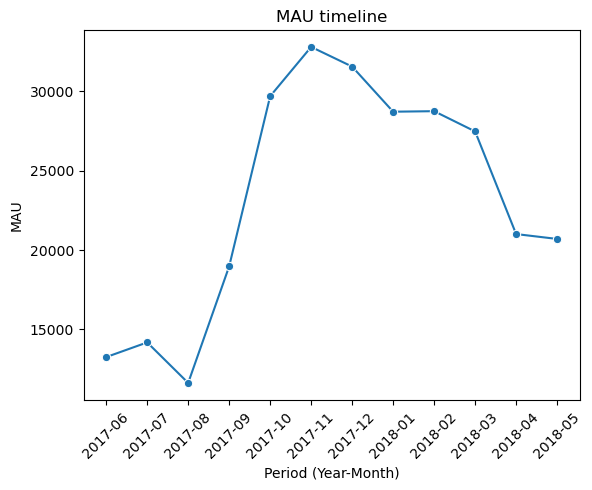

In [297]:
# Creamos la columna "period" 
visits["period"] = visits["start_ts"].dt.strftime("%Y-%m")

mau_timeline = visits.groupby("period").agg({"uid": "nunique"})

mau_lineplot = sns.lineplot(x="period", y="uid", marker="o", data=mau_timeline)

plt.title("MAU timeline")
plt.xlabel("Period (Year-Month)")
plt.ylabel("MAU")
plt.xticks(rotation=45);

>Nota: el dataset no cubre el período completo anunciado en las instrucciones del proyecto. Los primeros y últimos meses pueden mostrar valores atípicos por datos parciales, por lo que las tendencias de inicio y cierre deben interpretarse con cautela.

#### Conclusión

Se observan tres momentos clave en el período analizado. El punto más bajo de usuarios activos se registró en agosto de 2017, seguido de un crecimiento acelerado que alcanzó su punto máximo en noviembre del mismo año. A partir de diciembre de 2017 la actividad comenzó a disminuir de forma paulatina, lo cual es un comportamiento esperado después de un pico; sin embargo, los niveles de actividad no volvieron a los mínimos registrados al inicio del período, lo que sugiere un crecimiento neto positivo.

Este comportamiento podría explicarse por una campaña de marketing exitosa y una mayor inversión publicitaria en ese período. Si esta hipótesis se confirma al revisar los costos de adquisición, el equipo de marketing debería identificar qué canales fueron más activos entre septiembre y noviembre de 2017 para evaluar si la estrategia es replicable.

### ¿Cuántas sesiones hay por día?

Creamos la agrupación *daily_sessions* para determinar el numero de sesiones que hay por dia en la plataforma

In [298]:
# Contamos el numero de sesiones registradas y el numero de usuarios únicos por dia
daily_sessions = visits.groupby("date").agg({"uid": ["count", "nunique"]})
daily_sessions.columns = ["n_sessions", "n_users"]

# Calculamos las sesiones promedio por usuario
daily_sessions["sessions_per_user"] = daily_sessions["n_sessions"] / daily_sessions["n_users"]

print(daily_sessions["sessions_per_user"].describe())

count   364.00
mean      1.08
std       0.02
min       1.00
25%       1.07
50%       1.08
75%       1.09
max       1.22
Name: sessions_per_user, dtype: float64


#### Conclusión

En promedio se registran 1.08 sesiones por usuario al día, lo que indica que la gran mayoría de usuarios visita la plataforma una sola vez, con un pequeño porcentaje que genera más de una sesión diaria.

### ¿Cuál es la duración de cada sesión?

Para obtener la duración de una sesión bastara con restar el tiempo de inicio del tiempo de finalización

In [299]:
visits["session_duration_sec"] = (visits["end_ts"] - visits["start_ts"]).dt.seconds

Creamos un histograma para observar la distribución de la duración de las sesiones

Se eliminaron sesiones mayores a 30 minutos (7.76% del total) ya que superan el tiempo razonable para completar una compra, considerando variaciones de conectividad y tiempo de decisión del usuario. Estas sesiones probablemente representan navegadores abandonados.

Text(0, 0.5, 'Sessions Count')

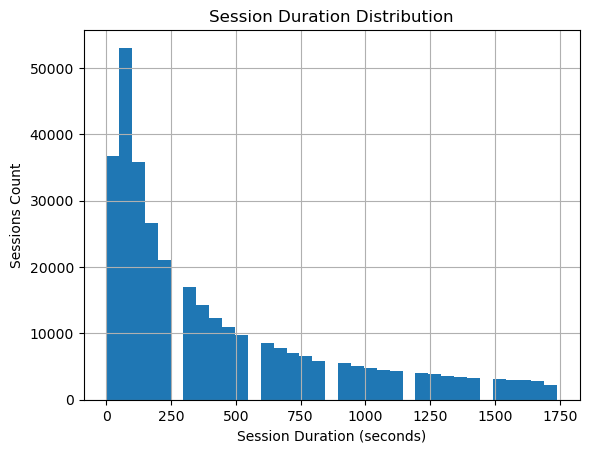

In [300]:
filtered_duration = visits[visits["session_duration_sec"] < 1800]

filtered_duration["session_duration_sec"].hist(bins=35)

plt.title("Session Duration Distribution")
plt.xlabel("Session Duration (seconds)")
plt.ylabel("Sessions Count")

In [301]:
print(f"La duracion mediana de sesion es de {int(filtered_duration["session_duration_sec"].median())} segundos")

La duracion mediana de sesion es de 240 segundos


#### Conclusión

La duración mediana de sesión es de 240 segundos (4 minutos), lo que indica que la mitad de los usuarios completan su visita en menos de ese tiempo. Se usa la mediana en lugar de la media debido al sesgo positivo de la distribución. 

### ¿Con qué frecuencia los usuarios regresan?

Contamos la cantidad de sesiones de cada usuario y filtramos a los usuarios que tengan mas de una sesión registrada

In [302]:
user_visits = visits["uid"].value_counts()

returning_users = user_visits > 1

# Calculamos el porcentaje de usuarios que visitaron mas de una vez la plataforma
returning_users_percent = returning_users.sum() / len(user_visits) * 100

print(f"El porcentaje de usuarios que regresan a la plataforma es: {returning_users_percent:.2f}%")
print(f"El sticky factor es: {sticky_factor[0]:.2f}") # Se obtuvo cuando calculamos DAU, WAU y MAU


El porcentaje de usuarios que regresan a la plataforma es: 22.85%
El sticky factor es: 0.04


#### Conclusión

El sticky factor mensual de Showz es de 0.04, lo que indica que en un día típico solo el 4% de los usuarios activos del mes visita la plataforma, un comportamiento esperado dado que la compra de entradas no es una actividad diaria. Por otro lado, el 22.85% de los usuarios regresa a la plataforma al menos una vez, lo que representa una base de clientes recurrentes considerable. Identificar por qué regresan, ya sea por comparación de precios, indecisión o compras frecuentes, podría abrir oportunidades para estrategias de retención y marketing dirigido.

## Ventas

### ¿Cuándo empieza la gente a comprar?

Obtenemos la primer visita registrada de cada usuario 

In [303]:
user_first_visit = visits.groupby("uid").agg({"start_ts": "min"}).reset_index()

user_first_visit["first_visit_cohort"] = user_first_visit["start_ts"].dt.strftime("%Y-%m")

user_first_visit.columns = ["uid", "first_visit", "first_visit_cohort"]


Unimos la información resultante en un nuevo dataset `orders_cohort`

In [304]:
orders_cohort = pd.merge(orders, user_first_visit, on="uid", how="inner")

orders_cohort.head()

,buy_ts,revenue,uid,first_visit,first_visit_cohort
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:09:00,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:14:00,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:25:00,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:14:00,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:31:00,2017-06


Buscamos la primer compra registrada de cada usuario

In [305]:
user_first_order = orders_cohort.groupby("uid").agg({"buy_ts": "min"}).reset_index()

user_first_order.columns = ["uid", "first_order"]

Unimos la información en el nuevo dataset `user_convertion`

In [306]:
user_convertion = pd.merge(orders_cohort, user_first_order, on="uid", how="inner")

Buscamos el tiempo que le toma a un usuario realizar su primera compra

Text(0, 0.5, 'Users')

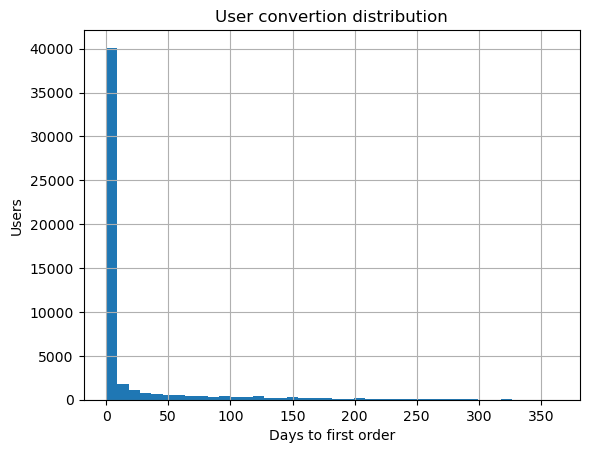

In [307]:
user_convertion["convertion_days"] = (user_convertion["first_order"] - user_convertion["first_visit"]).dt.days

user_convertion["convertion_days"].hist(bins=40)

plt.title("User convertion distribution")
plt.xlabel("Days to first order")
plt.ylabel("Users")

Calculamos el porcentaje de usuarios que realizaron una compra el primer dia de su visita

In [308]:
first_day_user_convertion = (user_convertion["convertion_days"] == 0).sum()
first_day_user_convertion_percent = first_day_user_convertion / len(user_convertion) * 100

print(f"El porcentaje de usuarios que realizaron una compra el primer dia de su visita es del {first_day_user_convertion_percent:.2f}%")

El porcentaje de usuarios que realizaron una compra el primer dia de su visita es del 67.91%


#### Conclusión

El 67.9% de los usuarios realizó su primera compra el mismo día de su primera visita, lo que sugiere una alta intención de compra desde el primer contacto con la plataforma. Esto podría explicarse por campañas de marketing bien dirigidas, confianza en la marca o precios competitivos. Analizar el comportamiento del 32.1% restante, usuarios que tardaron más de un día en convertir, podría revelar áreas de mejora en el proceso de compra o nuevas oportunidades para campañas de retención.

### ¿Cuántos pedidos hacen durante un período de tiempo dado?

Agrupamos por mes y año de compra y contamos los id's para obtener el numero de pedidos realizados a lo largo del tiempo

In [309]:
orders["period"] = orders["buy_ts"].dt.strftime("%Y-%m")

orders_by_month = orders.groupby(["period"]).agg({"uid": "count"}).reset_index()

orders_by_month.columns = ["period", "n_orders"]

Creamos un gráfico de lineas para observar la evolución de las ventas

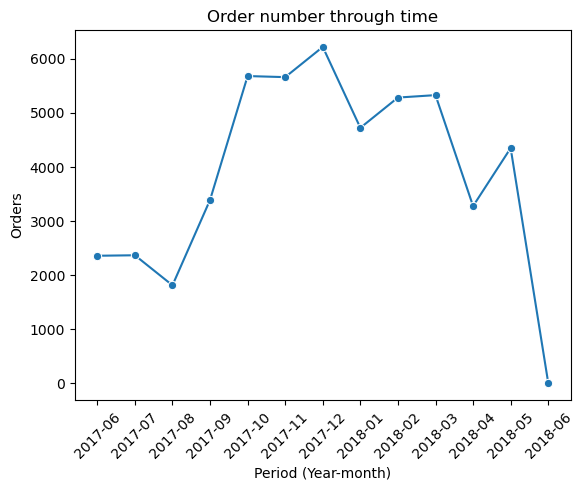

In [310]:
orders_line_plot = sns.lineplot(x="period", y="n_orders", data=orders_by_month, marker="o")

plt.title("Order number through time")
plt.xlabel("Period (Year-month)")
plt.ylabel("Orders")
plt.xticks(rotation=45);


In [311]:
orders["buy_ts"].describe()

count                            50415
mean     2017-12-20 05:14:24.846176768
min                2017-06-01 00:10:00
25%                2017-10-13 17:28:00
50%                2017-12-21 14:12:00
75%                2018-03-02 16:10:00
max                2018-06-01 00:02:00
Name: buy_ts, dtype: object

#### Conclusión

El pico de ventas se registró en diciembre de 2017, comportamiento consistente con la estacionalidad navideña, donde la compra de entradas como regalo es un factor relevante. Se recomienda al equipo de marketing preparar campañas dirigidas con anticipación a estas fechas para maximizar el volumen de conversiones.

Tras el pico, se observan caídas moderadas en enero y marzo de 2018, posiblemente relacionadas con la contracción del gasto post-navideño. La caída brusca de junio 2018 no representa una tendencia real, ya que el dataset solo contiene registros del primer día de ese mes.

Cabe destacar que el volumen de órdenes es considerablemente menor al MAU, lo que indica que no todos los visitantes se convierten en compradores. Calcular la tasa de conversión mensual sería un análisis complementario valioso para entender mejor la eficiencia del funnel de ventas.

##### Tasa de conversion

In [312]:
# Calculamos el numero de compradores unicos
unique_buyers = orders.groupby("period").agg({"uid": "nunique"}).reset_index()
unique_buyers.columns = ["period", "unique_buyers"]

# Obtenemos MAU 
mau = visits.groupby(["period"]).agg({"uid": "nunique"}).reset_index()
mau.columns = ["period", "mau"]

# Unimos las dos series
convertion = pd.merge(mau, unique_buyers, on="period", how="inner")

# Calculamos la tasa de conversion
convertion["convertion_rate"] = convertion["unique_buyers"] / convertion["mau"] * 100

print(f"La tasa de conversion promedio es del {convertion["convertion_rate"].mean():.2f}%")

La tasa de conversion promedio es del 14.62%


Creamos un gráfico de linea para observar la evolución de la tasa de conversion en cada periodo

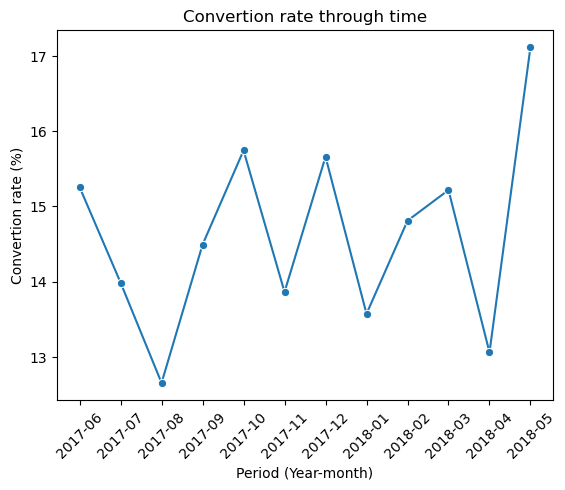

In [313]:
sns.lineplot(x="period", y="convertion_rate", data=convertion, marker="o")

plt.title("Convertion rate through time")
plt.xlabel("Period (Year-month)")
plt.ylabel("Convertion rate (%)")
plt.xticks(rotation=45);

La tasa de conversión promedio del período es de 14.62%, significativamente superior al rango típico del ecommerce general (1-4%), lo que sugiere una base de usuarios con alta intención de compra.
Sin embargo, se observa inestabilidad a lo largo del tiempo. Destaca que noviembre de 2017, el mes con mayor actividad de usuarios, no coincide con el pico de conversión, lo que indica que un mayor volumen de visitas no garantiza una mayor proporción de compras. Identificar las causas de estas fluctuaciones podría ayudar al equipo de marketing a estabilizar y mejorar la tasa de conversión.

### ¿Cuál es el tamaño promedio de compra?

Creamos un diagrama de caja para saber si existen valores atípicos extremos y decidir si se usa la media o la mediana

<Axes: ylabel='revenue'>

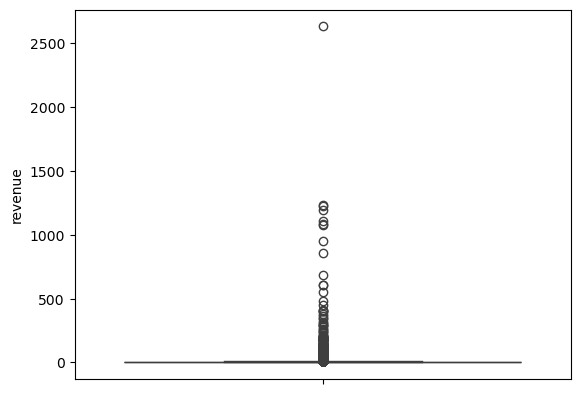

In [314]:
sns.boxplot(data=orders, y="revenue")

In [315]:
print(orders["revenue"].describe())

count   50,415.00
mean         5.00
std         21.82
min          0.00
25%          1.22
50%          2.50
75%          4.89
max      2,633.28
Name: revenue, dtype: float64


> Se identificaron 51 órdenes con revenue de 0 (0.1% del total). Podrían representar promociones, cupones o errores de registro. Al ser un volumen marginal se conservan en el análisis pero no afectan significativamente las métricas

Debido a que existen valores atípicos extremos que pueden afectar el calculo de la media utilizaremos la mediana como referencia

#### Conclusión

El valor mediano de las transacciones es de $2.50, con el 75% de las órdenes por debajo de $4.89, lo que indica que la gran mayoría de las compras son de ticket bajo. Sin embargo, existen transacciones que superan significativamente ese rango, llegando hasta $2,633 en una sola venta, lo que sugiere que existe un segmento de clientes de alto valor. Analizar el comportamiento de estos clientes podría proporcionar al equipo de marketing ideas para desarrollar estrategias de upselling y cross-selling orientadas a incrementar el ticket promedio.

### ¿Cuánto dinero traen? (LTV)

Calculamos el tiempo de vida de cada cohorte

In [316]:
orders_cohort["cohorts_lifetime"] = ((orders_cohort["buy_ts"] - orders_cohort["first_visit"]).dt.days / 30).round().astype("int")

Calculamos el tamaño de cada cohorte (¿Cuantos usuarios hay en cada una?)

In [317]:
cohort_sizes = user_first_visit.groupby("first_visit_cohort").agg({"uid": "nunique"})
cohort_sizes.columns = ["n_users"]


Calculamos las ganancias de cada cohorte

In [318]:
cohorts = orders_cohort.groupby(["first_visit_cohort", "cohorts_lifetime"]).agg({"revenue": "sum"}).reset_index()

Unimos nuestras series

In [319]:
cohorts = pd.merge(cohorts, cohort_sizes, on="first_visit_cohort", how="inner")

Calculamos el LTV

In [320]:
cohorts["ltv"] = cohorts["revenue"] / cohorts["n_users"]

Creamos una tabla dinámica y aplicamos cumsum para ver el LTV acumulado de cada cohorte

In [321]:
cohorts_pivot = cohorts.pivot_table(index="first_visit_cohort",
                                    columns="cohorts_lifetime",
                                    values="ltv",
                                    aggfunc="mean")

cohorts_pivot = cohorts_pivot.cumsum(axis=1)

print(cohorts_pivot)

cohorts_lifetime     0    1    2    3    4    5    6    7    8    9    10  \
first_visit_cohort                                                          
2017-06            0.72 0.89 1.00 1.20 1.54 1.74 2.02 2.17 2.36 2.62 2.77   
2017-07            0.76 0.82 0.91 0.98 1.05 1.11 1.15 1.22 1.27 1.31 1.34   
2017-08            0.63 0.72 0.82 0.91 0.98 1.03 1.09 1.19 1.29 1.32 1.32   
2017-09            0.77 0.95 1.08 1.66 1.79 1.91 1.95 1.99 2.01 2.02  NaN   
2017-10            0.72 0.84 0.91 0.94 0.99 1.02 1.04 1.07 1.07  NaN  NaN   
2017-11            0.63 0.71 0.76 0.81 0.85 0.87 0.89 0.90  NaN  NaN  NaN   
2017-12            0.67 0.73 0.90 1.10 1.17 1.23 1.23  NaN  NaN  NaN  NaN   
2018-01            0.49 0.56 0.61 0.62 0.64 0.64  NaN  NaN  NaN  NaN  NaN   
2018-02            0.53 0.61 0.64 0.67 0.68  NaN  NaN  NaN  NaN  NaN  NaN   
2018-03            0.58 0.63 0.66 0.67  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2018-04            0.52 0.61 0.63  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

Creamos un heatmap visualizar nuestros datos

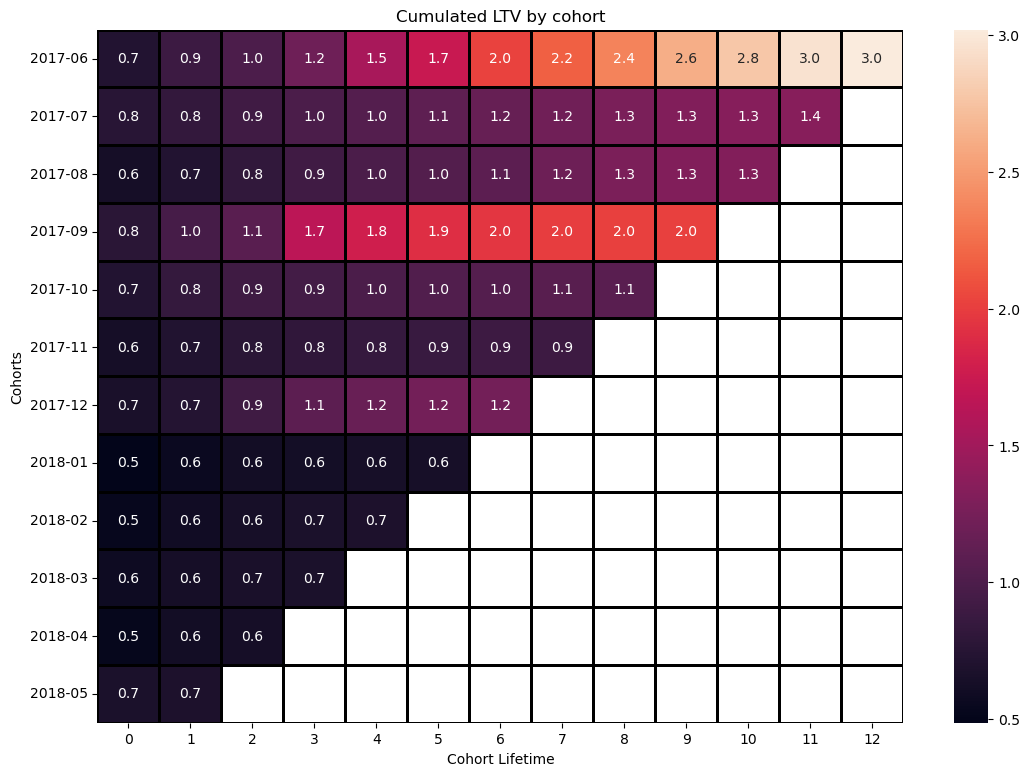

In [322]:

plt.figure(figsize=(13,9))

sns.heatmap(cohorts_pivot,
            annot=True,
            fmt=".1f",
            linewidths=1,
            linecolor="black")

plt.title("Cumulated LTV by cohort")
plt.xlabel("Cohort Lifetime")
plt.ylabel("Cohorts");


#### Conclusión

Las cohortes de 2017 presentan un LTV mayor al de las cohortes de 2018, lo cual es esperado dado su mayor tiempo de vida en la plataforma. Destacan dos cohortes: junio 2017 por su crecimiento sostenido a lo largo del tiempo, y septiembre 2017 por un salto notable en su tercer mes de vida, que corresponde a diciembre, consistente con la estacionalidad navideña identificada anteriormente.

Se observan períodos de estancamiento en varias cohortes, donde el LTV acumulado deja de crecer, indicando que los usuarios dejaron de comprar. Identificar en qué mes ocurre este estancamiento para cada cohorte podría ayudar al equipo de marketing a diseñar campañas de reactivación dirigidas justo antes de ese punto.

## Marketing

### ¿Cuánto dinero se gastó? 

In [323]:
total_costs = costs["costs"].sum()

source_costs = costs.groupby("source_id").agg({"costs": "sum"})

# Creamos la columna periodo para dividir las fechas en meses y años
costs["period"] = costs["dt"].dt.strftime("%Y-%m")

costs_through_time = costs.groupby("period").agg({"costs": "sum"})

print(f"El costo total de las campañas de marketing es de: ${total_costs}")
print()
print(f"Los gastos por fuente de mayor a menor son:\n {source_costs.sort_values("costs", ascending=False)}")
print()
print(f"Los gastos por periodo son:\n {costs_through_time}")

El costo total de las campañas de marketing es de: $329131.62

Los gastos por fuente de mayor a menor son:
                costs
source_id           
3         141,321.63
4          61,073.60
5          51,757.10
2          42,806.04
1          20,833.27
10          5,822.49
9           5,517.49

Los gastos por periodo son:
             costs
period           
2017-06 18,015.00
2017-07 18,240.59
2017-08 14,790.54
2017-09 24,368.91
2017-10 36,322.88
2017-11 37,907.88
2017-12 38,315.35
2018-01 33,518.52
2018-02 32,723.03
2018-03 30,415.27
2018-04 22,289.38
2018-05 22,224.27


In [324]:
source_3_percent = (source_costs.loc[3, "costs"] / total_costs * 100).astype("float")

print(f"El porcentaje de gastos de la fuente 3 sobre el total es de {source_3_percent:.2f}%")

El porcentaje de gastos de la fuente 3 sobre el total es de 42.94%


#### Conclusión

El gasto total en marketing durante el período fue de $329,131.62, distribuido principalmente en la fuente 3, que concentra el 42.9% del presupuesto total. Se observa una correlación clara entre el gasto en marketing y la actividad en la plataforma: agosto de 2017, el mes con menor inversión ($14,790), coincide con el punto más bajo de visitas y órdenes. A partir de septiembre el presupuesto aumentó progresivamente hasta alcanzar su pico en diciembre de 2017 ($38,315), alineado con la estacionalidad navideña. Desde enero de 2018 el presupuesto comenzó a reducirse gradualmente, lo que podría explicar la caída en el MAU observada en el mismo período

###  ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

Agregamos la columna **source_id** de nuestro dataset `visits` al dataset `orders_cohort` el cual contiene información de los usuarios que realizaron una compra 

In [338]:
orders_with_source = orders_cohort.merge(visits[["uid", "source_id"]], on="uid", how="inner")

Obtenemos el numero de compradores unicos

In [339]:
source_buyers = orders_with_source.groupby("source_id")["uid"].nunique()

Calculamos el CAC

In [340]:
cac = source_costs["costs"] / source_buyers

print(cac)

source_id
1     2.92
2     5.86
3    10.21
4     4.28
5     5.10
7      NaN
9     1.98
10    3.28
dtype: float64


#### Conclusión

El CAC más alto corresponde a la fuente 3 ($10.21), que también es la que mayor presupuesto consume. Las fuentes 9 y 1 presentan los CAC más bajos ($1.98 y $2.92 respectivamente). La fuente 7 no registra compradores asociados a pesar de tener costos, lo que representa una pérdida de inversión que requiere investigación. No se encontraron registros para la fuente 6.

### ¿Cuán rentables eran las inversiones? (ROMI)

Calculamos el LTV por fuente 

In [342]:
source_revenue = orders_with_source.groupby("source_id")["revenue"].sum()

source_ltv = source_revenue / source_buyers

print(source_ltv)

source_id
1    321.97
2    361.15
3     21.43
4     34.85
5    116.33
7      1.22
9     13.01
10     8.25
dtype: float64


Calculamos el ROMI

In [343]:
romi = (source_ltv - cac) / cac

print(romi)


source_id
1    109.31
2     60.63
3      1.10
4      7.13
5     21.83
7       NaN
9      5.59
10     1.51
dtype: float64


# Conclusión general y recomendaciones

El siguiente análisis cubre el período de junio 2017 a mayo 2018 para Showz, plataforma de venta de entradas, con el objetivo de optimizar la inversión en marketing.
Los principales hallazgos son:

El 67.9% de los usuarios convierte el mismo día de su primera visita, lo que indica una base de usuarios con alta intención de compra. Las campañas deben enfocarse en atraer usuarios con intención clara más que en volumen general.

Se identificó una estacionalidad marcada entre septiembre y diciembre, con picos en visitas, órdenes y LTV. Se recomienda concentrar mayor inversión en marketing durante ese período y preparar campañas con anticipación.

El hallazgo más crítico es la ineficiencia de la fuente 3: consume el 42.9% del presupuesto total ($141,321) pero genera el ROMI más bajo (1.10). En contraste, la fuente 1 logra el ROMI más alto (109.31) con una fracción del presupuesto ($20,833). Se recomienda redirigir gradualmente el presupuesto de la fuente 3 hacia la fuente 1, e incrementar gradualmente la inversión en la fuente 9, que muestra mejor rendimiento que fuentes con presupuesto similar.
Finalmente, las fuentes 6 y 7 requieren investigación: la fuente 7 registra costos sin compradores asociados y la fuente 6 no tiene registros en el período analizado.
Limitación principal: el dataset no incluye nombres de fuentes ni catálogo de precios, lo que impide identificar los canales específicos y calcular márgenes reales